# GBM: Simulating Price Paths

**pyportfolios.com tutorial T01** · SPY, Jan 2018 – Dec 2024 · NumPy · Pandas · Matplotlib · yfinance · SciPy

Geometric Brownian Motion is the workhorse stochastic process of quantitative finance —
the engine inside Black–Scholes, Monte-Carlo pricing, and every "wealth projection cone"
you have ever seen. In this notebook we

1. estimate GBM parameters (drift μ, volatility σ) from real SPY data,
2. simulate 5,000 price paths one year forward,
3. read scenario percentiles off the simulated cone, and
4. test where the model breaks (spoiler: the tails).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42

## 1 · Data: SPY adjusted closes

We work with the S&P 500 ETF (SPY, State Street) from January 2018 through December 2024 —
a sample that conveniently contains a melt-up, the COVID crash, a bear market, and two
recoveries.

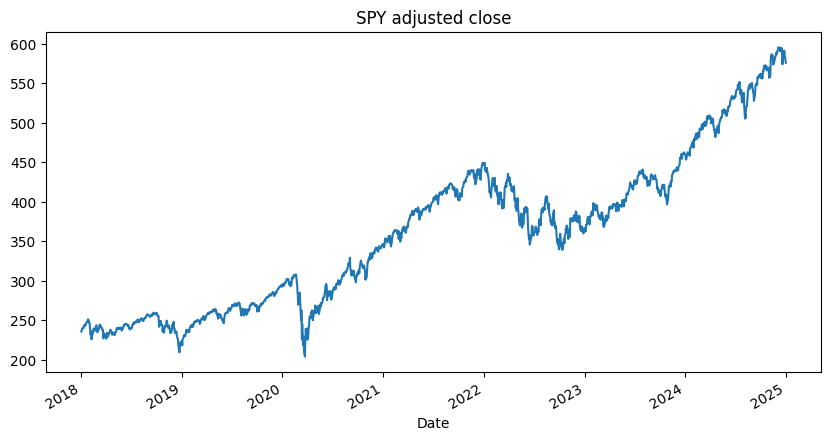

In [2]:
px = yf.download("SPY", start="2018-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].squeeze().dropna()
px.plot(title="SPY adjusted close");

## 2 · Estimating μ and σ

GBM says $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$, which makes **log returns**
i.i.d. normal: $\ln(S_{t+\Delta}/S_t) \sim \mathcal N\big((\mu - \tfrac{\sigma^2}{2})\Delta,\ \sigma^2 \Delta\big)$.
So the estimators are just the sample mean and standard deviation of daily log returns,
annualised by 252.

In [3]:
logret = np.log(px / px.shift(1)).dropna()

mu_annual    = logret.mean() * 252
sigma_annual = logret.std(ddof=1) * np.sqrt(252)
s0 = float(px.iloc[-1])

print(f"mu     = {mu_annual: .4f}  per year")
print(f"sigma  = {sigma_annual: .4f}  per year")
print(f"S0     = {s0:.2f}")

mu     =  0.1278  per year
sigma  =  0.1953  per year
S0     = 576.22


## 3 · Simulating paths

The exact discretisation (no Euler error) is

$$S_{t+\Delta} = S_t \exp\Big[(\mu - \tfrac{\sigma^2}{2})\Delta + \sigma\sqrt{\Delta}\,Z\Big], \quad Z \sim \mathcal N(0,1).$$

Vectorised over a matrix of standard normals, 5,000 one-year paths cost milliseconds.

In [4]:
rng = np.random.default_rng(SEED)
n_paths, horizon, dt = 5000, 252, 1/252

z = rng.standard_normal((n_paths, horizon))
increments = (mu_annual - 0.5 * sigma_annual**2) * dt + sigma_annual * np.sqrt(dt) * z
paths = s0 * np.exp(np.cumsum(increments, axis=1))
paths = np.hstack([np.full((n_paths, 1), s0), paths])
paths.shape

(5000, 253)

## 4 · The scenario cone

Percentiles across paths at each date give the classic wealth-projection cone. This is
exactly how robo-advisors draw "likely range of outcomes" charts — and how desks stress
a book against a distribution of scenarios rather than one point forecast.

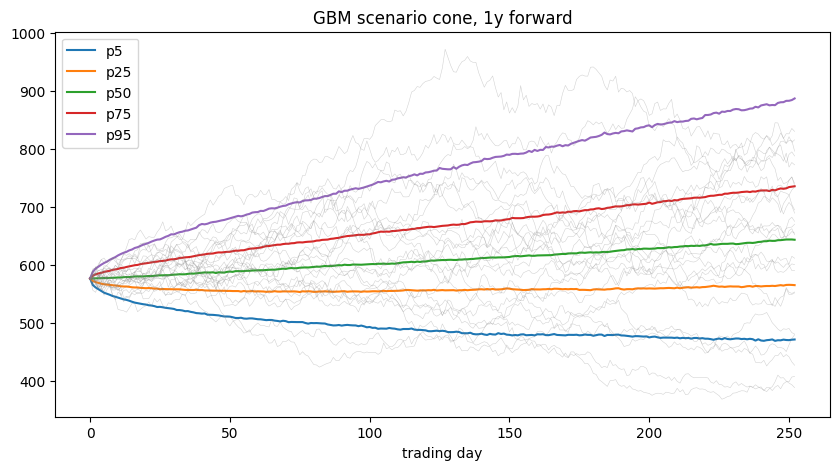

In [5]:
t = np.arange(paths.shape[1])
for p in (5, 25, 50, 75, 95):
    plt.plot(t, np.percentile(paths, p, axis=0), label=f"p{p}")
plt.plot(t, paths[:24].T, lw=0.4, alpha=0.35, color="grey")
plt.legend(); plt.title("GBM scenario cone, 1y forward"); plt.xlabel("trading day");

## 5 · Terminal distribution

At the horizon GBM implies a **lognormal** terminal price. Overlaying the analytic
lognormal density on the simulated histogram is a free correctness check of the
simulation — they should agree to Monte-Carlo error.

p 5:   471.08
p25:   564.73
p50:   642.93
p75:   735.12
p95:   886.40
P(loss after 1y) = 28.3%


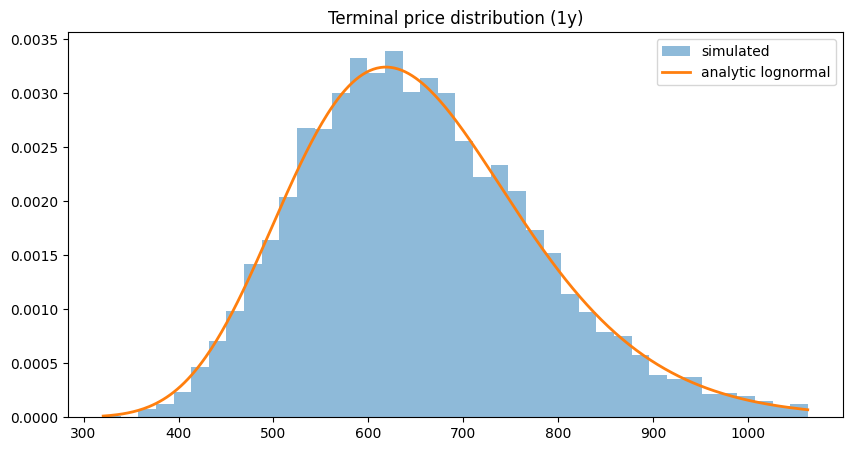

In [6]:
terminal = paths[:, -1]

edges = np.linspace(terminal.min(), np.percentile(terminal, 99.5), 41)
plt.hist(terminal, bins=edges, density=True, alpha=0.5, label="simulated")

ln_mu    = np.log(s0) + (mu_annual - 0.5 * sigma_annual**2)
ln_sigma = sigma_annual
grid = np.linspace(edges[0], edges[-1], 400)
plt.plot(grid, stats.lognorm.pdf(grid, s=ln_sigma, scale=np.exp(ln_mu)),
         lw=2, label="analytic lognormal")
plt.legend(); plt.title("Terminal price distribution (1y)");

for p in (5, 25, 50, 75, 95):
    print(f"p{p:>2}: {np.percentile(terminal, p):8.2f}")
print(f"P(loss after 1y) = {(terminal < s0).mean():.1%}")

## 6 · Where the model breaks

GBM's returns are normal; real returns are not. Jarque–Bera rejects normality
emphatically, and the excess kurtosis quantifies how much fatter the real tails are.
That is why GBM cones are fine for *central* scenarios and dangerous for *tail* risk —
the subject of the VaR and CVaR tutorials (T09, T10).

In [7]:
jb = stats.jarque_bera(logret)
print(f"Jarque-Bera stat = {jb.statistic:,.1f}   p-value = {jb.pvalue:.2e}")
print(f"excess kurtosis  = {stats.kurtosis(logret):.2f}   (normal = 0)")
print(f"skew             = {stats.skew(logret):.2f}   (normal = 0)")

Jarque-Bera stat = 11,650.9   p-value = 0.00e+00
excess kurtosis  = 12.50   (normal = 0)
skew             = -0.80   (normal = 0)


## Takeaways

- μ and σ from log returns fully specify GBM; the exact discretisation has zero scheme error.
- 5,000 paths → a scenario cone and a terminal distribution in milliseconds.
- The analytic lognormal matches the simulation — always run this sanity check.
- Real SPY returns have ~10× the excess kurtosis GBM assumes: use GBM for scenario
  *shapes*, never for tail sizing.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*